In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

V3LE_ROOT = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper")
V3LE_FIG_ROOT = V3LE_ROOT / "figures"
V3LE_DIAG_DIR = V3LE_ROOT / "diag_data"
FIG_DIR_ROOT = V3LE_FIG_ROOT / "arctic_amplification/65n_driftcorr"

In [1]:
from __future__ import annotations

import os
import glob
from typing import Dict, Optional, Sequence, Tuple, Union

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.colorbar import ColorbarBase
from matplotlib.path import Path
from matplotlib.ticker import FixedLocator
from matplotlib.colors import TwoSlopeNorm

# inset colorbars & axes helpers
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import colormaps as mpl_cmaps


In [2]:
class ArcticDiagnosticsMapPlotter:
    """
    Plot precomputed diagnostics from ArcticAmplificationDiagnostics:
      per season -> Dataset (or path) with:
        - 'trend_dec' (K/decade)
        - 'aa_map'    (dimensionless)

    Convenience:
      - discover_saved_means(): find mean files by pattern
      - plot_compare(): one 2x2 figure (Trend/AA × ExpA/ExpB) for a season
      - plot_compare_from_dirs(): make one figure per season using file discovery

    NEW:
      - Ensemble member support via `members_glob_A/B` (patterns may include {season})
      - Variability overlays via `stippling_for`, e.g. {"trend": "low_agreement", "aa": "high_cv"}
      - Optionally use dotted stippling (cleaner than hatches for large areas)
      - Adaptive thresholds via quantiles in plot_compare_from_dirs()
    """

    # ------------------------ init ------------------------
    def __init__(
        self,
        *,
        fig_dir: Optional[str] = None,
        fontz: int = 12,
        lat_name: str = "lat",
        lon_name: str = "lon",
    ):
        self.fig_dir = fig_dir or "."
        self.fontz = int(fontz)
        self.lat_name = lat_name
        self.lon_name = lon_name
        self.set_font_defaults()

    # ---------- font helpers ----------
    def fs(self, mult: float = 1.0) -> float:
        return float(self.fontz) * float(mult)

    def set_font_defaults(self):
        plt.rcParams.update({
            "font.size":                  self.fs(1.0),
            "axes.titlesize":             self.fs(1.2),
            "axes.labelsize":             self.fs(1.0),
            "xtick.labelsize":            self.fs(0.95),
            "ytick.labelsize":            self.fs(0.95),
            "legend.fontsize":            self.fs(0.95),
            "figure.titlesize":           self.fs(1.4),
            "figure.constrained_layout.use": False,  # we set per-figure below
        })
        # lighter hatch strokes for readability
        mpl.rcParams["hatch.linewidth"] = 0.4

    # ---------- color utils ----------
    @staticmethod
    def _cmap(name: str):
        # Future-proof access to colormaps (Matplotlib ≥3.7)
        return mpl_cmaps.get_cmap(name)

    @staticmethod
    def _ensure_monotonic_edges(edges: np.ndarray) -> np.ndarray:
        edges = np.asarray(edges, float)
        if edges.ndim != 1 or edges.size < 3:
            raise ValueError("Edges must be a 1-D array with at least 3 entries.")
        if not np.all(np.diff(edges) > 0):
            edges = np.unique(edges)
            if not np.all(np.diff(edges) > 0):
                raise ValueError("Edges must be strictly increasing.")
        return edges

    def _make_discrete_blue_red(self, edges, *, extend="neither", blues="Blues", reds="Reds"):
        edges = self._ensure_monotonic_edges(edges)
        if not np.any(np.isclose(edges, 1.0)):
            raise ValueError("AA edges must include 1.0.")
        i1 = int(np.where(np.isclose(edges, 1.0))[0][0])
        n_bins = edges.size - 1
        n_below = i1
        n_above = n_bins - n_below

        colors_interior = []
        if n_below > 0:
            colors_interior += list(self._cmap(blues)(np.linspace(0.30, 0.01, n_below)))
        if n_above > 0:
            colors_interior += list(self._cmap(reds)(np.linspace(0.10, 0.80, n_above)))

        colors = []
        if extend in ("min", "both"):
            colors.append(self._cmap(blues)(0.70))
        colors.extend(colors_interior)
        if extend in ("max", "both"):
            colors.append(self._cmap(reds)(0.98))

        cmap = mcolors.ListedColormap(colors)
        if extend in ("min", "both"):
            cmap.set_under(colors[0])
        if extend in ("max", "both"):
            cmap.set_over(colors[-1])

        norm = mcolors.BoundaryNorm(edges, cmap.N, extend=extend)
        return cmap, norm

    def _make_discrete_diverging(self, edges, *, extend="both", blues="BuGn", reds="YlOrBr"):
        edges = self._ensure_monotonic_edges(edges)
        if not np.any(np.isclose(edges, 0.0)):
            raise ValueError("Trend edges must include 0.0.")
        i0 = int(np.where(np.isclose(edges, 0.0))[0][0])
        n_bins = edges.size - 1
        n_neg = i0
        n_pos = n_bins - n_neg

        colors_interior = []
        if n_neg > 0:
            colors_interior += list(self._cmap(blues)(np.linspace(0.90, 0.10, n_neg)))
        if n_pos > 0:
            colors_interior += list(self._cmap(reds)(np.linspace(0.10, 0.90, n_pos)))

        colors = []
        if extend in ("min", "both"):
            colors.append(self._cmap(blues)(0.99))
        colors.extend(colors_interior)
        if extend in ("max", "both"):
            colors.append(self._cmap(reds)(0.99))

        cmap = mcolors.ListedColormap(colors)
        if extend in ("min", "both"):
            cmap.set_under(colors[0])
        if extend in ("max", "both"):
            cmap.set_over(colors[-1])

        norm = mcolors.BoundaryNorm(edges, cmap.N, extend=extend)
        return cmap, norm

    # ---------- map helpers ----------
    def _pmesh(self, use_polar, ax, lon, lat, data, **pc_kwargs):
        HAVE_CARTOPY = False
        if use_polar:
            try:
                import cartopy.crs as ccrs  # noqa: F401
                HAVE_CARTOPY = True
            except Exception:
                use_polar = False
        if use_polar and HAVE_CARTOPY:
            import cartopy.crs as ccrs
            return ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), **pc_kwargs)
        return ax.pcolormesh(lon, lat, data, **pc_kwargs)

    def _prep(self, use_polar, m: xr.DataArray, *, dateline_stitch: bool):
        HAVE_CARTOPY = False
        add_cyclic_point = None
        if use_polar:
            try:
                import cartopy.crs as ccrs  # noqa: F401
                from cartopy.util import add_cyclic_point as _acp
                HAVE_CARTOPY = True
                add_cyclic_point = _acp
            except Exception:
                use_polar = False

        lon = m[self.lon_name]; lat = m[self.lat_name]
        if use_polar and HAVE_CARTOPY and dateline_stitch and lon.ndim == 1:
            data_c, lon_c = add_cyclic_point(m.values, coord=lon.values, axis=-1)
            return lon_c, lat.values, data_c
        return (lon.values if lon.ndim == 1 else lon), lat.values, m.values

    def _subset(self, m: xr.DataArray, lo: float, hi: float):
        lat = m[self.lat_name]
        if float(lat[0]) > float(lat[-1]):
            return m.sel({self.lat_name: slice(hi, lo)})
        return m.sel({self.lat_name: slice(lo, hi)})

    # ---------- saved-output discovery ----------
    @staticmethod
    def _infer_period_from_attrs(path: str) -> Tuple[Optional[int], Optional[int], Optional[str], Optional[str]]:
        """Return (analysis_start, analysis_end, group, var_name) from dataset attrs if available."""
        try:
            with xr.open_dataset(path) as ds:
                a0 = int(ds.attrs.get("analysis_start")) if "analysis_start" in ds.attrs else None
                a1 = int(ds.attrs.get("analysis_end"))   if "analysis_end"   in ds.attrs else None
                grp = ds.attrs.get("group")
                var = ds.attrs.get("var_name")
            return a0, a1, grp, var
        except Exception:
            return None, None, None, None

    def discover_saved_means(
        self,
        out_dir: str,
        prefix: str = "AA",
        seasons: Optional[Sequence[str]] = None,
        *,
        start_end: Optional[Tuple[int, int]] = None,
        pattern: Optional[str] = None,
    ) -> Dict[str, str]:
        """
        Find ensemble-mean files written by ArcticAmplificationDiagnostics.save_all().

        Default filenames: "{prefix}_mean_{SEASON}_{start}-{end}.nc".
        If start_end is unknown, glob "{prefix}_mean_{SEASON}_*.nc" and take the newest.
        """
        out_dir = out_dir or "."
        os.makedirs(out_dir, exist_ok=True)
        if seasons is None:
            seasons = ("MON", "DJF", "MAM", "JJA", "SON", "ANN")

        diag_by_season: Dict[str, str] = {}
        for s in (str(x).upper() for x in seasons):
            if pattern is None:
                if start_end is not None:
                    y0, y1 = start_end
                    pat = f"{prefix}_mean_{s}_{y0}-{y1}.nc"
                else:
                    pat = f"{prefix}_mean_{s}_*.nc"
            else:
                y0, y1 = (start_end or ("*", "*"))
                pat = pattern.format(prefix=prefix, season=s, start=y0, end=y1)

            cand = sorted(glob.glob(os.path.join(out_dir, pat)))
            if not cand:
                alt = sorted(glob.glob(os.path.join(out_dir, pat.replace(f"{prefix}_", ""))))
                cand = alt

            if not cand:
                print(f"[WARN] No file found for season {s!r} with pattern: {pat}")
                continue

            best = max(cand, key=os.path.getmtime)
            diag_by_season[s] = best

        if not diag_by_season:
            raise FileNotFoundError(f"No season files discovered in {out_dir} (prefix={prefix}).")
        return diag_by_season

    # ---------- labeled grids (lon labels outside; lat labels inside) ----------
    def _add_polar_grids(
        self, ax, *, central_longitude: float = 0.0,
        parallels=(60, 70, 80),
        meridians=tuple(range(-180, 181, 30)),
        label_lon: float = 0.0,
        label_fmt: str = r"{lat:.0f}°N",
        grid_kw: dict | None = None,
        lat_label_offset_deg: float = 0.8,
    ):
        grid_kw = dict(linestyle="--", linewidth=0.6, alpha=0.5, color="k") | (grid_kw or {})
        try:
            import cartopy.crs as ccrs
            from cartopy.mpl.ticker import LongitudeFormatter
            import matplotlib.patheffects as pe
        except Exception:
            return

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            xlocs=meridians,
            ylocs=parallels,
            linestyle=grid_kw["linestyle"],
            linewidth=grid_kw["linewidth"],
            alpha=grid_kw["alpha"],
            color=grid_kw["color"],
            rotate_labels=False,
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False
        gl.xformatter = LongitudeFormatter(number_format=".0f", degree_symbol="°")
        gl.xlabel_style = {"size": max(8, int(self.fontz * 0.8))}
        gl.ylabel_style = {"size": max(8, int(self.fontz * 0.8))}

        for lat in parallels:
            lat_in = min(89.5, float(lat) + float(lat_label_offset_deg))
            ax.text(
                float(label_lon), lat_in, label_fmt.format(lat=lat),
                transform=ccrs.PlateCarree(), ha="left", va="center",
                fontsize=max(8, int(self.fontz * 0.85)),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.5, pad=1.5),
                zorder=10,
                path_effects=[pe.withStroke(linewidth=1.0, foreground="white", alpha=0.8)],
            )

    # ---------- ensemble helpers ----------
    def _normalize_member_dim(self, da: xr.DataArray, src: str, offset: int) -> xr.DataArray:
        member_aliases = ("member", "ens", "ensemble", "nEns", "nMember")
        rename = {}
        if "latitude" in da.dims and self.lat_name not in da.dims:
            rename["latitude"] = self.lat_name
        if "longitude" in da.dims and self.lon_name not in da.dims:
            rename["longitude"] = self.lon_name
        if rename:
            da = da.rename(rename)

        mdim = next((d for d in da.dims if d in member_aliases), None)
        if mdim is None:
            da = da.expand_dims(member=[os.path.basename(src)])
            return da

        if mdim != "member":
            da = da.rename({mdim: "member"})

        mem_coord = da.get_index("member") if "member" in da.coords else None
        if mem_coord is None or np.issubdtype(getattr(mem_coord, "dtype", np.int64), np.number):
            n = da.sizes["member"]
            da = da.assign_coords(member=np.arange(offset, offset + n))
        return da

    def _load_members_stack(self, paths: list[str], var_name: str) -> xr.DataArray:
        arrs = []
        offset = 0
        for p in paths:
            ds = xr.open_dataset(p)
            if var_name not in ds:
                raise KeyError(f"{p} missing variable {var_name!r}")
            da = ds[var_name]
            da = self._normalize_member_dim(da, src=p, offset=offset)
            offset += da.sizes["member"]
            arrs.append(da)
        if len(arrs) == 1:
            return arrs[0]
        return xr.concat(arrs, dim="member")

    @staticmethod
    def _ensemble_stats(stack: xr.DataArray) -> dict[str, xr.DataArray]:
        mean = stack.mean("member", skipna=True)
        std = stack.std("member", skipna=True)
        eps = xr.full_like(mean, 1e-12)
        cv = std / xr.where(np.abs(mean) > eps, np.abs(mean), eps)
        sign_mean = xr.apply_ufunc(np.sign, mean)
        sign_mem  = xr.apply_ufunc(np.sign, stack)
        agree = (sign_mem == sign_mean)
        denom = xr.apply_ufunc(np.isfinite, stack).sum("member")
        sign_agree = agree.sum("member") / xr.where(denom > 0, denom, 1)
        return {"mean": mean, "std": std, "cv": cv, "sign_agree": sign_agree}
    
    def _overlay_stippling(self, use_polar, ax, lon, lat, mask,
                           *, stride=5, size=3.0, marker=".", color="k", alpha=0.6):
        if lon.ndim == 1 and lat.ndim == 1:
            LON, LAT = np.meshgrid(lon, lat)
        else:
            LON, LAT = lon, lat
        m = np.asarray(mask, bool)
        if not m.any():
            return
        # Downsample for clarity
        if stride > 1:
            m = m[::stride, ::stride]
            LON = LON[::stride, ::stride]
            LAT = LAT[::stride, ::stride]
        LONv = LON[m]
        LATv = LAT[m]
        if use_polar:
            import cartopy.crs as ccrs
            ax.scatter(LONv, LATv, transform=ccrs.PlateCarree(),
                       s=size, marker=marker, color=color, alpha=alpha, linewidths=0)
        else:
            ax.scatter(LONv, LATv, s=size, marker=marker, color=color, alpha=alpha, linewidths=0)

        
    def _overlay_hatching(
        self, use_polar: bool, ax, lon, lat, mask: np.ndarray,
        *, hatch: str = "///", zorder: int = 12, antialiased: bool = False,
    ):
        # pcolormesh-like single-level hatched overlay
        if lon.ndim == 1 and lat.ndim == 1:
            LON, LAT = np.meshgrid(lon, lat)
        else:
            LON, LAT = lon, lat
        m = np.asarray(mask, bool)
        if not m.any():
            return
        vals = np.where(m, 1.0, np.nan)

        HAVE_CARTOPY = False
        if use_polar:
            try:
                import cartopy.crs as ccrs
                HAVE_CARTOPY = True
            except Exception:
                use_polar = False

        kwargs = dict(levels=[0.5, 1.5], colors="none", hatches=[hatch],
                      antialiased=antialiased, zorder=zorder)
        if use_polar and HAVE_CARTOPY:
            import cartopy.crs as ccrs
            ax.contourf(LON, LAT, vals, transform=ccrs.PlateCarree(), **kwargs)
        else:
            ax.contourf(LON, LAT, vals, **kwargs)

    def _overlay_dots(
        self, use_polar: bool, ax, lon, lat, mask: np.ndarray,
        *, stride: int = 4, size: float = 4.0, marker: str = ".", zorder: int = 12
    ):
        # sparse dotted overlay (publication-friendly)
        if lon.ndim == 1 and lat.ndim == 1:
            LON, LAT = np.meshgrid(lon, lat)
        else:
            LON, LAT = lon, lat
        m = np.asarray(mask, bool)
        if not m.any():
            return
        sl = (slice(0, None, stride), slice(0, None, stride))
        yy, xx = np.where(m[sl])
        xs = LON[sl][yy, xx]
        ys = LAT[sl][yy, xx]

        HAVE_CARTOPY = False
        if use_polar:
            try:
                import cartopy.crs as ccrs
                HAVE_CARTOPY = True
            except Exception:
                use_polar = False

        if use_polar and HAVE_CARTOPY:
            import cartopy.crs as ccrs
            ax.scatter(xs, ys, s=size, marker=marker, transform=ccrs.PlateCarree(),
                       linewidths=0, facecolors="none", edgecolors="k", zorder=zorder)
        else:
            ax.scatter(xs, ys, s=size, marker=marker,
                       linewidths=0, facecolors="none", edgecolors="k", zorder=zorder)

    def _maybe_cyclic_mask(self, mask: np.ndarray, lon) -> np.ndarray:
        try:
            lon = np.asarray(lon)
            m = np.asarray(mask)
            if lon.ndim == 1 and m.ndim == 2 and lon.size == m.shape[1] + 1:
                mask = np.concatenate([m, m[:, :1]], axis=1)
        except Exception:
            pass
        return mask

    def _mask_from_stats(self, stats, kind: str, *, agree_lo: float, agree_hi: float,
                         cv_hi: float, std_hi: float):
        if stats is None:
            return None
        if kind == "low_agreement":
            return (stats["sign_agree"] < agree_lo).values
        if kind == "high_agreement":
            return (stats["sign_agree"] > agree_hi).values
        if kind == "high_cv":
            return (stats["cv"] > cv_hi).values
        if kind == "high_std":
            return (stats["std"] > std_hi).values
        return None

    def _member_paths(self, glob_pat: Optional[str], season: str) -> list[str]:
        if not glob_pat:
            return []
        return sorted(glob.glob(glob_pat.format(season=season)))

    def process_ensemble_stats(
        self,
        *,
        members_glob: str | None,
        season: str,
        lat_slice: tuple[float, float],
        decim_stride: int,
        decim_sel: dict[str, slice],
        agree_lo_q: float | None = 0.20,
        agree_hi_q: float | None = None,
        cv_hi_q:    float | None = 0.80,
        std_hi_q:   float | None = None,
        agree_lo_fallback: float = 0.80,
        agree_hi_fallback: float = 0.90,
        cv_hi_fallback:    float = 0.50,
        std_hi_fallback:   float = 0.50,
    ) -> tuple[dict | None, float, float, float, float]:

        thr_agree_lo = float(agree_lo_fallback)
        thr_agree_hi = float(agree_hi_fallback)
        thr_cv_hi    = float(cv_hi_fallback)
        thr_std_hi   = float(std_hi_fallback)

        if not members_glob:
            return None, thr_agree_lo, thr_agree_hi, thr_cv_hi, thr_std_hi

        paths = self._member_paths(members_glob, season)
        if not paths:
            print(f"[WARN] No ensemble files matched for season {season}: {members_glob!r}")
            return None, thr_agree_lo, thr_agree_hi, thr_cv_hi, thr_std_hi

        try:
            stack_t = self._load_members_stack(paths, "trend_dec")
        except Exception:
            stack_t = None
        try:
            stack_a = self._load_members_stack(paths, "aa_map")
        except Exception:
            stack_a = None

        if stack_t is None and stack_a is None:
            return None, thr_agree_lo, thr_agree_hi, thr_cv_hi, thr_std_hi

        lo, hi = lat_slice
        if stack_t is not None:
            stack_t = self._subset(stack_t, lo, hi)
            if decim_stride > 1:
                stack_t = stack_t.isel(decim_sel)
        if stack_a is not None:
            stack_a = self._subset(stack_a, lo, hi)
            if decim_stride > 1:
                stack_a = stack_a.isel(decim_sel)

        base = stack_t if stack_t is not None else stack_a
        nmem = int(base.sizes.get("member", 1))
        if nmem < 5:
            print(f"[INFO] season {season}: only {nmem} members — using fallbacks.")
            return None, thr_agree_lo, thr_agree_hi, thr_cv_hi, thr_std_hi

        def _stats(x): return self._ensemble_stats(x) if x is not None else None
        st_t = _stats(stack_t)
        st_a = _stats(stack_a)
        stats = {"trend": st_t, "aa": st_a}

        def _q(da, q):
            if da is None or q is None:
                return None
            try:
                return float(da.quantile(float(q)))
            except Exception:
                return None

        if st_t is not None:
            v = _q(st_t["sign_agree"], agree_lo_q)
            if v is not None: thr_agree_lo = max(0.0, min(1.0, v))
            v = _q(st_t["sign_agree"], agree_hi_q)
            if v is not None: thr_agree_hi = max(0.0, min(1.0, v))

        src = st_a if st_a is not None else st_t
        if src is not None:
            v = _q(src["cv"],  cv_hi_q);  thr_cv_hi  = float(v) if v is not None else thr_cv_hi
            v = _q(src["std"], std_hi_q); thr_std_hi = float(v) if v is not None else thr_std_hi

        return stats, thr_agree_lo, thr_agree_hi, thr_cv_hi, thr_std_hi

    def _compute_dynamic_thresholds(
        self,
        stack_t,
        stack_a,
        agree_lo_q: float | None = 0.20,
        agree_hi_q: float | None = None,
        cv_hi_q:    float | None = 0.80,
        std_hi_q:   float | None = None,
        agree_lo_fallback: float = 0.80,
        agree_hi_fallback: float = 0.90,
        cv_hi_fallback:    float = 0.50,
        std_hi_fallback:   float = 0.50,
    ) -> tuple[float, float, float, float]:
        agree_lo = float(agree_lo_fallback)
        agree_hi = float(agree_hi_fallback)
        cv_hi    = float(cv_hi_fallback)
        std_hi   = float(std_hi_fallback)

        # Return defaults only if BOTH stacks are missing
        if stack_t is None and stack_a is None:
            return agree_lo, agree_hi, cv_hi, std_hi

        stacks = [x for x in (stack_t, stack_a) if x is not None]
        if not stacks:
            return agree_lo, agree_hi, cv_hi, std_hi
        nmem = int(stacks[0].sizes.get("member", 1))
        if nmem < 5:
            return agree_lo, agree_hi, cv_hi, std_hi

        def _stats(x): return self._ensemble_stats(x) if x is not None else None
        st_t = _stats(stack_t)
        st_a = _stats(stack_a)

        def _q(da, q):
            if da is None or q is None:
                return None
            try:
                return float(da.quantile(float(q)))
            except Exception:
                return None

        if st_t is not None:
            v = _q(st_t["sign_agree"], agree_lo_q)
            if v is not None: agree_lo = max(0.0, min(1.0, v))
            v = _q(st_t["sign_agree"], agree_hi_q)
            if v is not None: agree_hi = max(0.0, min(1.0, v))

        src = st_a if st_a is not None else st_t
        if src is not None:
            v = _q(src["cv"],  cv_hi_q);  cv_hi  = float(v) if v is not None else cv_hi
            v = _q(src["std"], std_hi_q); std_hi = float(v) if v is not None else std_hi

        return agree_lo, agree_hi, cv_hi, std_hi

    # ---------- main API: per-season 2x2 comparison ----------
    def plot_compare(
        self,
        *,
        diag_A_by_season: dict[str, str | xr.Dataset],
        diag_B_by_season: dict[str, str | xr.Dataset],
        season: str,
        exp_A: str,
        exp_B: str,
        # colorbars
        trend_vmax: float | None = None,
        trend_cmap: str = "RdBu_r",
        trend_robust: float = 2.0,
        trend_edges: tuple[float, ...] | None = None,
        trend_extend: str = "both",
        trend_name: str = "Linear trend",
        trend_unit: str = "°C / decade",
        aa_edges: tuple[float, ...] | None = None,
        aa_extend: str = "both",
        aa_name: str = "Arctic Amplification",
        aa_unit: str = "ratio",
        # layout / projection
        figsize: tuple[float, float] = (11.0, 8.5),
        dpi: int = 150,
        use_polar: bool = True,
        projection: str = "north_polar",
        central_longitude: float = 0.0,
        circular_boundary: bool = True,
        add_coastlines: bool = True,
        add_grids: bool = True,
        grid_parallels: tuple[int, ...] = (60, 70, 80),
        grid_meridians: tuple[int, ...] = (-180, -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150, 180),
        grid_label_lon: float = 0.0,
        grid_kwargs: dict | None = None,
        subset_lat: tuple[float, float] = (60.0, 90.0),
        max_cells: int = 200_000,
        stride: int | None = None,
        rasterize: bool = True,
        dateline_stitch: bool = True,
        title: str | None = None,
        out_path: str | None = None,
        show: bool = True,
        wspace: float = 0.04,
        hspace: float = 0.08,
        # layout & colorbar controls
        constrained: bool = True,
        cbar_shrink: float = 0.75,
        cbar_pad: float = 0.02,
        cbar_fraction: float = 0.046,
        # ----- NEW: ensemble & stippling -----
        members_glob_A: str | None = None,
        members_glob_B: str | None = None,
        stippling_for: dict | None = None,
        agree_hi: float = 0.8,
        agree_lo: float = 0.6,
        cv_hi: float = 0.5,
        std_hi: float = 0.5,
        # quantile knobs (None => skip quantile, use fallbacks)
        agree_lo_q: float | None = None,
        agree_hi_q: float | None = None,
        cv_hi_q:    float | None = None,
        std_hi_q:   float | None = None,
        stippling_stride: int = 3,
        stippling_size: float = 3.0,
        # NEW: dots vs hatch
        stippling_mode: str = "hatch",         # "hatch" | "dots"
        dots_marker: str = ".",
    ):
        """Make one 2×2 figure for a single season comparing two experiments."""
        s = season.upper()
        srcA = diag_A_by_season[s]
        srcB = diag_B_by_season[s]
        
        opened = []
        try:
            dA = xr.open_dataset(srcA) if isinstance(srcA, str) else srcA
            dB = xr.open_dataset(srcB) if isinstance(srcB, str) else srcB
            if isinstance(srcA, str): opened.append(dA)
            if isinstance(srcB, str): opened.append(dB)
            for tag, d in (("A", dA), ("B", dB)):
                if ("trend_dec" not in d) or ("aa_map" not in d):
                    raise KeyError(f"[{s} {tag}] dataset must contain 'trend_dec' and 'aa_map'.")

            tA = dA["trend_dec"]; aA = dA["aa_map"]
            tB = dB["trend_dec"]; aB = dB["aa_map"]

            # subset & decimate
            lo, hi = subset_lat
            tA = self._subset(tA, lo, hi); aA = self._subset(aA, lo, hi)
            tB = self._subset(tB, lo, hi); aB = self._subset(aB, lo, hi)

            ny = int(tA.sizes[self.lat_name]); nx = int(tA.sizes[self.lon_name])
            sdec = (int(np.ceil(np.sqrt(ny * nx / max_cells))) if (stride is None and ny * nx > max_cells)
                    else int(max(1, stride or 1)))
            if sdec > 1:
                sl = {self.lat_name: slice(0, None, sdec), self.lon_name: slice(0, None, sdec)}
                tA = tA.isel(sl); aA = aA.isel(sl)
                tB = tB.isel(sl); aB = aB.isel(sl)

            # ---------- optional: load ensemble members & compute stats ----------
            statsA, agree_loA, agree_hiA, cv_hiA, std_hiA = self.process_ensemble_stats(
                members_glob=members_glob_A,
                season=s,
                lat_slice=subset_lat,
                decim_stride=sdec,
                decim_sel=sl if sdec > 1 else {self.lat_name: slice(None), self.lon_name: slice(None)},
                agree_lo_q=agree_lo_q,
                agree_hi_q=agree_hi_q,
                cv_hi_q=cv_hi_q,
                std_hi_q=std_hi_q,
                agree_lo_fallback=agree_lo,   # from plot_compare kwargs
                agree_hi_fallback=agree_hi,
                cv_hi_fallback=cv_hi,
                std_hi_fallback=std_hi,
            )
            
            statsB, agree_loB, agree_hiB, cv_hiB, std_hiB = self.process_ensemble_stats(
                members_glob=members_glob_B,
                season=s,
                lat_slice=subset_lat,
                decim_stride=sdec,
                decim_sel=sl if sdec > 1 else {self.lat_name: slice(None), self.lon_name: slice(None)},
                agree_lo_q=agree_lo_q,
                agree_hi_q=agree_hi_q,
                cv_hi_q=cv_hi_q,
                std_hi_q=std_hi_q,
                agree_lo_fallback=agree_lo,
                agree_hi_fallback=agree_hi,
                cv_hi_fallback=cv_hi,
                std_hi_fallback=std_hi,
            )

            # ---------- shared color scaling ----------
            use_discrete_trend = trend_edges is not None
            if use_discrete_trend:
                trend_edges_arr = self._ensure_monotonic_edges(np.asarray(trend_edges, float))
                cmap_trend, norm_trend = self._make_discrete_diverging(trend_edges_arr, extend=trend_extend)
                trend_color_kwargs = {"cmap": cmap_trend, "norm": norm_trend}
                trend_ticks_edges = trend_edges_arr
            else:
                joined = np.concatenate([
                    np.ravel(np.asarray(tA.values, float)),
                    np.ravel(np.asarray(tB.values, float)),
                ])
                joined = joined[np.isfinite(joined)]
                if trend_vmax is None:
                    if joined.size:
                        loq, hiq = np.nanpercentile(joined, [trend_robust, 100 - trend_robust])
                        trend_vmax = float(max(0.1, max(abs(loq), abs(hiq))))
                    else:
                        trend_vmax = 1.0
                trend_norm = TwoSlopeNorm(vmin=-trend_vmax, vcenter=0.0, vmax=trend_vmax)
                cmap_trend = self._cmap(trend_cmap)
                trend_color_kwargs = {"cmap": cmap_trend, "norm": trend_norm}
                trend_ticks_edges = np.linspace(-trend_vmax, trend_vmax, 13)

            if aa_edges is None:
                aa_edges_arr = np.array([0.5, 1.0, 2.0, 3.0, 4.0], dtype=float)
            else:
                aa_edges_arr = self._ensure_monotonic_edges(np.asarray(aa_edges, float))
                if not np.any(np.isclose(aa_edges_arr, 1.0)):
                    raise ValueError("aa_edges must include 1.0.")
            cmap_aa, norm_aa = self._make_discrete_blue_red(aa_edges_arr, extend=aa_extend)

            # ---------- figure & axes ----------
            HAVE_CARTOPY = False
            if use_polar:
                try:
                    import cartopy.crs as ccrs
                    HAVE_CARTOPY = True
                except Exception:
                    print("[WARN] Cartopy not available; falling back to lat/lon plot.")
                    use_polar = False

            if use_polar and HAVE_CARTOPY:
                proj = (ccrs.NorthPolarStereo(central_longitude=central_longitude)
                        if projection == "north_polar"
                        else ccrs.LambertAzimuthalEqualArea(central_longitude=central_longitude, central_latitude=90))
                fig = plt.figure(figsize=figsize, dpi=dpi, constrained_layout=bool(constrained))
                gs = fig.add_gridspec(2, 2, wspace=wspace, hspace=hspace)
                axT_A = fig.add_subplot(gs[0, 0], projection=proj)
                axT_B = fig.add_subplot(gs[0, 1], projection=proj)
                axA_A = fig.add_subplot(gs[1, 0], projection=proj)
                axA_B = fig.add_subplot(gs[1, 1], projection=proj)
            else:
                fig, axarr = plt.subplots(
                    2, 2, figsize=figsize, dpi=dpi, squeeze=False, constrained_layout=bool(constrained)
                )
                axT_A, axT_B, axA_A, axA_B = axarr[0, 0], axarr[0, 1], axarr[1, 0], axarr[1, 1]

            # ---------- prep arrays ----------
            lonTA, latTA, datTA = self._prep(use_polar, tA, dateline_stitch=dateline_stitch)
            lonTB, latTB, datTB = self._prep(use_polar, tB, dateline_stitch=dateline_stitch)
            lonAA, latAA, datAA = self._prep(use_polar, aA, dateline_stitch=dateline_stitch)
            lonAB, latAB, datAB = self._prep(use_polar, aB, dateline_stitch=dateline_stitch)

            # ---------- map cosmetics ----------
            if use_polar and HAVE_CARTOPY:
                for ax in (axT_A, axT_B, axA_A, axA_B):
                    ax.set_extent([-180, 180, subset_lat[0], subset_lat[1]], crs=ccrs.PlateCarree())
                    if circular_boundary:
                        theta = np.linspace(0, 2*np.pi, 256)
                        circle = Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5)
                        ax.set_boundary(circle, transform=ax.transAxes)
                    if add_coastlines: ax.coastlines(linewidth=0.5)
                    if add_grids:
                        self._add_polar_grids(ax, central_longitude=central_longitude,
                                              parallels=grid_parallels, meridians=grid_meridians,
                                              label_lon=grid_label_lon, grid_kw=grid_kwargs)

            # ---------- draw maps ----------
            imT_A = self._pmesh(use_polar, axT_A, lonTA, latTA, datTA, shading="auto",
                                edgecolors="none", linewidth=0.0, rasterized=bool(rasterize),
                                **trend_color_kwargs)
            imT_B = self._pmesh(use_polar, axT_B, lonTB, latTB, datTB, shading="auto",
                                edgecolors="none", linewidth=0.0, rasterized=bool(rasterize),
                                **trend_color_kwargs)
            imA_A = self._pmesh(use_polar, axA_A, lonAA, latAA, datAA, shading="auto",
                                edgecolors="none", linewidth=0.0, rasterized=bool(rasterize),
                                cmap=cmap_aa, norm=norm_aa)
            imA_B = self._pmesh(use_polar, axA_B, lonAB, latAB, datAB, shading="auto",
                                edgecolors="none", linewidth=0.0, rasterized=bool(rasterize),
                                cmap=cmap_aa, norm=norm_aa)

            # ---------- titles ----------
            titles = [
                f"(a) {exp_A} (Trend)",
                f"(b) {exp_B} (Trend)",
                f"(c) {exp_A} (AA)",
                f"(d) {exp_B} (AA)",
            ]
            for ax, ttl in zip([axT_A, axT_B, axA_A, axA_B], titles):
                ax.set_title(ttl, loc="center", pad=3, fontsize=self.fontz * 1.0, fontweight="semibold")
                ax.title.set_y(1.15)

            # ---------- shared vertical colorbars per row ----------
            cbar_T = fig.colorbar(
                imT_B, ax=[axT_A, axT_B],
                location="right", fraction=cbar_fraction, pad=cbar_pad, shrink=cbar_shrink
            )
            cbar_T.set_label(f"Trend ({trend_unit})", fontsize=self.fontz * 0.9)
            cbar_T.ax.tick_params(labelsize=self.fontz * 0.8)
            if trend_edges is not None:
                cbar_T.set_ticks(trend_ticks_edges)
                cbar_T.ax.tick_params(length=3)

            cbar_AA = fig.colorbar(
                imA_B, ax=[axA_A, axA_B],
                location="right", fraction=cbar_fraction, pad=cbar_pad, shrink=cbar_shrink
            )
            cbar_AA.set_label(f"Local Amplification ({aa_unit})", fontsize=self.fontz * 0.9)
            cbar_AA.ax.tick_params(labelsize=self.fontz * 0.8)
            cbar_AA.set_ticks(aa_edges_arr)
            cbar_AA.ax.tick_params(length=3)

            # ---------- variability / agreement overlays ----------
            if stippling_for is None:
                stippling_for = {}

            # hatch mapping (lighter)
            hatch_map = {
                "low_agreement": "...",
                "high_agreement": "///",
                "high_cv": "xxx",
                "high_std": "\\",
            }

            # TREND
            if "trend" in stippling_for:
                kind = stippling_for["trend"]
                
                mA = self._mask_from_stats(statsA and statsA.get("trend"), kind,
                                           agree_lo=agree_loA, agree_hi=agree_hiA, cv_hi=cv_hiA, std_hi=std_hiA)
                mB = self._mask_from_stats(statsB and statsB.get("trend"), kind,
                                           agree_lo=agree_loB, agree_hi=agree_hiB, cv_hi=cv_hiB, std_hi=std_hiB)
                # --- diagnostic info ---
                if kind in ("low_agreement", "high_agreement", "high_cv", "high_std"):
                    msgA = (f"[{season} {exp_A} trend] kind={kind}, "
                            f"agree_lo={agree_loA:.3f}, agree_hi={agree_hiA:.3f}, "
                            f"cv_hi={cv_hiA:.3f}, std_hi={std_hiA:.3f}")
                    msgB = (f"[{season} {exp_B} trend] kind={kind}, "
                            f"agree_lo={agree_loB:.3f}, agree_hi={agree_hiB:.3f}, "
                            f"cv_hi={cv_hiB:.3f}, std_hi={std_hiB:.3f}")
                    print(msgA)
                    print(msgB)
                    
                if mA is not None:
                    mA = self._maybe_cyclic_mask(mA, lonTA)
                    if stippling_mode == "dots":
                        self._overlay_dots(
                            use_polar, axT_A, lonTA, latTA, mA,
                            stride=stippling_stride, size=stippling_size, marker=dots_marker, zorder=12
                        )
                    else:
                        self._overlay_hatching(
                            use_polar, axT_A, lonTA, latTA, mA,
                            hatch=hatch_map.get(kind, "."), zorder=12
                        )
                if mB is not None:
                    mB = self._maybe_cyclic_mask(mB, lonTB)
                    if stippling_mode == "dots":
                        self._overlay_dots(
                            use_polar, axT_B, lonTB, latTB, mB,
                            stride=stippling_stride, size=stippling_size, marker=dots_marker, zorder=12
                        )
                    else:
                        self._overlay_hatching(
                            use_polar, axT_B, lonTB, latTB, mB,
                            hatch=hatch_map.get(kind, "."), zorder=12
                        )

            # AA
            if "aa" in stippling_for:
                kind = stippling_for["aa"]

                # Per-experiment thresholds (computed earlier with process_ensemble_stats)
                mA = self._mask_from_stats(
                    statsA and statsA.get("aa"), kind,
                    agree_lo=agree_loA, agree_hi=agree_hiA, cv_hi=cv_hiA, std_hi=std_hiA
                )
                mB = self._mask_from_stats(
                    statsB and statsB.get("aa"), kind,
                    agree_lo=agree_loB, agree_hi=agree_hiB, cv_hi=cv_hiB, std_hi=std_hiB
                )
                if kind in ("low_agreement", "high_agreement", "high_cv", "high_std"):
                    msgA = (f"[{season} {exp_A} AA] kind={kind}, "
                            f"agree_lo={agree_loA:.3f}, agree_hi={agree_hiA:.3f}, "
                            f"cv_hi={cv_hiA:.3f}, std_hi={std_hiA:.3f}")
                    msgB = (f"[{season} {exp_B} AA] kind={kind}, "
                            f"agree_lo={agree_loB:.3f}, agree_hi={agree_hiB:.3f}, "
                            f"cv_hi={cv_hiB:.3f}, std_hi={std_hiB:.3f}")
                    print(msgA)
                    print(msgB)
                    
                if mA is not None:
                    mA = self._maybe_cyclic_mask(mA, lonAA)
                    if stippling_mode == "dots":
                        self._overlay_dots(
                            use_polar, axA_A, lonAA, latAA, mA,
                            stride=stippling_stride, size=stippling_size, marker=dots_marker, zorder=12
                        )
                    else:
                        self._overlay_hatching(
                            use_polar, axA_A, lonAA, latAA, mA,
                            hatch=hatch_map.get(kind, "/"), zorder=12
                        )

                if mB is not None:
                    mB = self._maybe_cyclic_mask(mB, lonAB)
                    if stippling_mode == "dots":
                        self._overlay_dots(
                            use_polar, axA_B, lonAB, latAB, mB,
                            stride=stippling_stride, size=stippling_size, marker=dots_marker, zorder=12
                        )
                    else:
                        self._overlay_hatching(
                            use_polar, axA_B, lonAB, latAB, mB,
                            hatch=hatch_map.get(kind, "/"), zorder=12
                        )

            # ---------- finalize ----------
            if title:
                fig.suptitle(title, fontsize=self.fontz * 1.05)

            if out_path is None:
                os.makedirs(self.fig_dir, exist_ok=True)
                out_path = os.path.join(
                    self.fig_dir,
                    f"Trend_AA_compare_{exp_A.replace(' ','_')}__vs__{exp_B.replace(' ','_')}_{s}.pdf"
                )

            if constrained:
                fig.set_constrained_layout_pads(w_pad=0.002, h_pad=0.01, wspace=wspace, hspace=hspace)
            else:
                fig.subplots_adjust(top=0.92, wspace=wspace, hspace=hspace)

            fig.savefig(out_path, dpi=dpi)
            if show:
                plt.show()
            print(f"[INFO] Saved: {out_path}")

            return fig, (axT_A, axT_B, axA_A, axA_B), {
                "trend_edges": trend_edges if use_discrete_trend else None,
                "aa_edges": aa_edges_arr.copy(),
                "out_path": out_path,
            }

        finally:
            for d in opened:
                try:
                    d.close()
                except Exception:
                    pass
                
    # ---------- wrapper: make one figure per season ----------
    def plot_compare_from_dirs(
        self,
        out_dir_A: str,
        out_dir_B: str,
        *,
        prefix_A: str,
        prefix_B: str,
        seasons: Sequence[str],
        start_end: tuple[int, int] | None = None,
        pattern: str | None = None,
        exp_A: str | None = None,
        exp_B: str | None = None,
        wspace: float = 0.04,
        hspace: float = 0.08,
        agree_lo_q: float | None = None,   # e.g., 0.10
        agree_hi_q: float | None = None,   # e.g., 0.95
        cv_hi_q: float | None = None,      # e.g., 0.75
        std_hi_q: float | None = None,     # optional
        **one_kwargs,
    ):
        """Discover files once, then emit one 2×2 figure per season."""
        diag_A = self.discover_saved_means(out_dir=out_dir_A, prefix=prefix_A,
                                           seasons=seasons, start_end=start_end, pattern=pattern)
        diag_B = self.discover_saved_means(out_dir=out_dir_B, prefix=prefix_B,
                                           seasons=seasons, start_end=start_end, pattern=pattern)

        if exp_A is None:
            any_path = next(iter(diag_A.values()))
            a0, a1, grp, var = self._infer_period_from_attrs(any_path)
            bits = []
            if grp: bits.append(grp)
            if var: bits.append(var)
            if (a0 is not None) and (a1 is not None): bits.append(f"{a0}–{a1}")
            exp_A = ".".join(bits) if bits else "Exp-A"
        if exp_B is None:
            any_path = next(iter(diag_B.values()))
            a0, a1, grp, var = self._infer_period_from_attrs(any_path)
            bits = []
            if grp: bits.append(grp)
            if var: bits.append(var)
            if (a0 is not None) and (a1 is not None): bits.append(f"{a0}–{a1}")
            exp_B = ".".join(bits) if bits else "Exp-B"
        results = {}
        # --- plot_compare_from_dirs: forward the knobs into k before calling plot_compare ---
        for s in [x.upper() for x in seasons]:
            k = dict(one_kwargs)
            k |= dict(
                agree_lo_q=agree_lo_q,
                agree_hi_q=agree_hi_q,
                cv_hi_q=cv_hi_q,
                std_hi_q=std_hi_q,
            )
            fig, axes, summary = self.plot_compare(
                diag_A_by_season=diag_A, diag_B_by_season=diag_B,
                season=s, exp_A=exp_A, exp_B=exp_B,
                wspace=wspace, hspace=hspace, **k
            )
            results[s] = summary["out_path"]
            
        return results


[INFO] season ANN: only 1 members — using fallbacks.
[ANN ERA5 trend] kind=low_agreement, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[ANN E3SMv3-LE trend] kind=low_agreement, agree_lo=0.960, agree_hi=1.000, cv_hi=0.234, std_hi=1.010
[ANN ERA5 AA] kind=high_cv, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[ANN E3SMv3-LE AA] kind=high_cv, agree_lo=0.960, agree_hi=1.000, cv_hi=0.234, std_hi=1.010


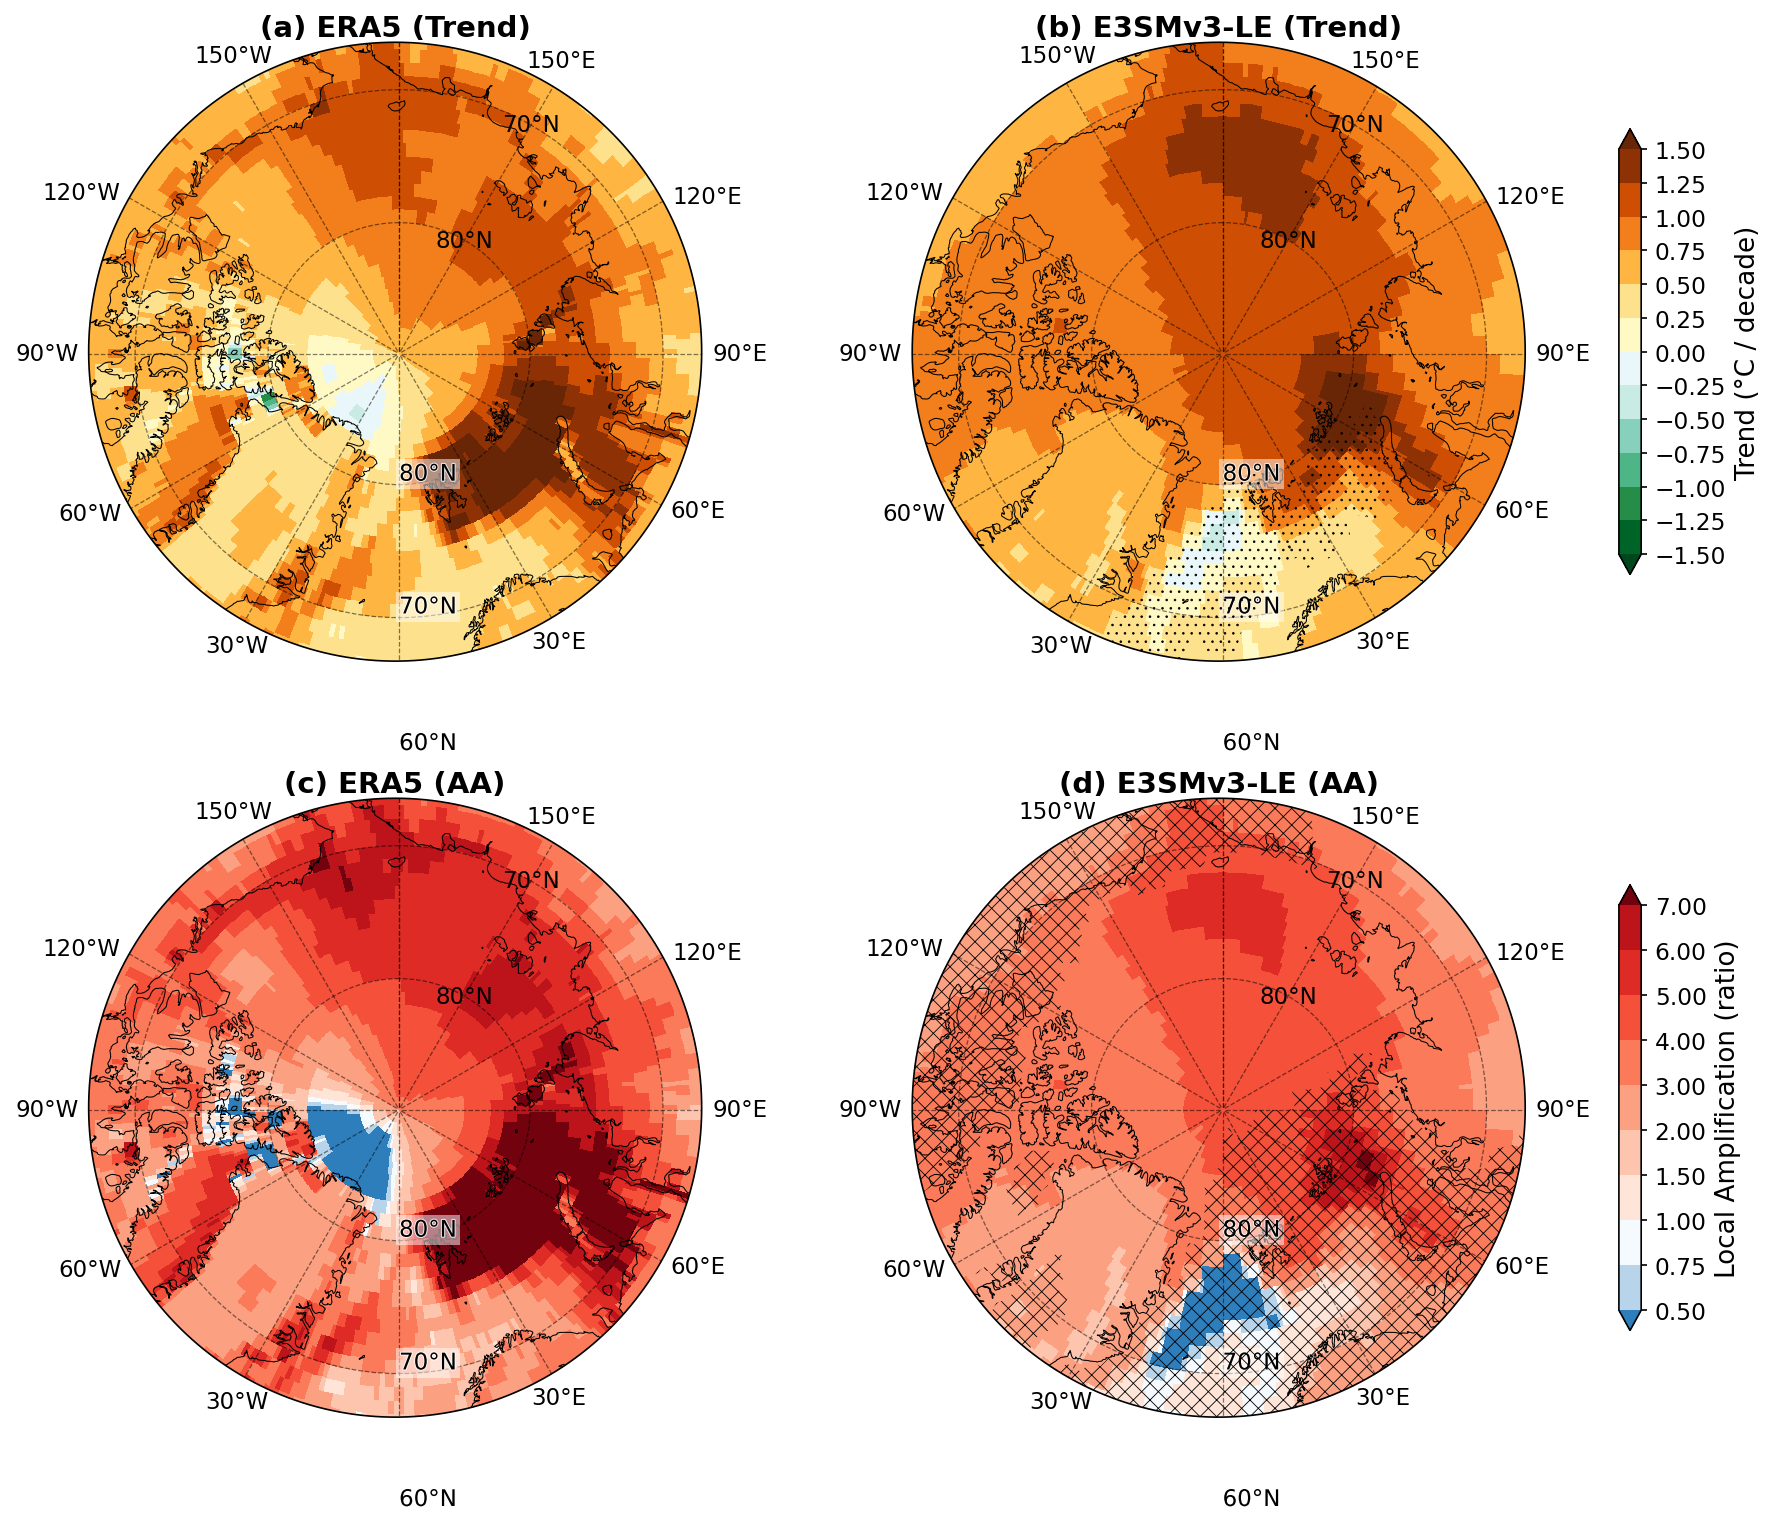

[INFO] Saved: ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_ANN.pdf
[INFO] season DJF: only 1 members — using fallbacks.
[DJF ERA5 trend] kind=low_agreement, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[DJF E3SMv3-LE trend] kind=low_agreement, agree_lo=0.920, agree_hi=1.000, cv_hi=0.300, std_hi=1.797
[DJF ERA5 AA] kind=high_cv, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[DJF E3SMv3-LE AA] kind=high_cv, agree_lo=0.920, agree_hi=1.000, cv_hi=0.300, std_hi=1.797


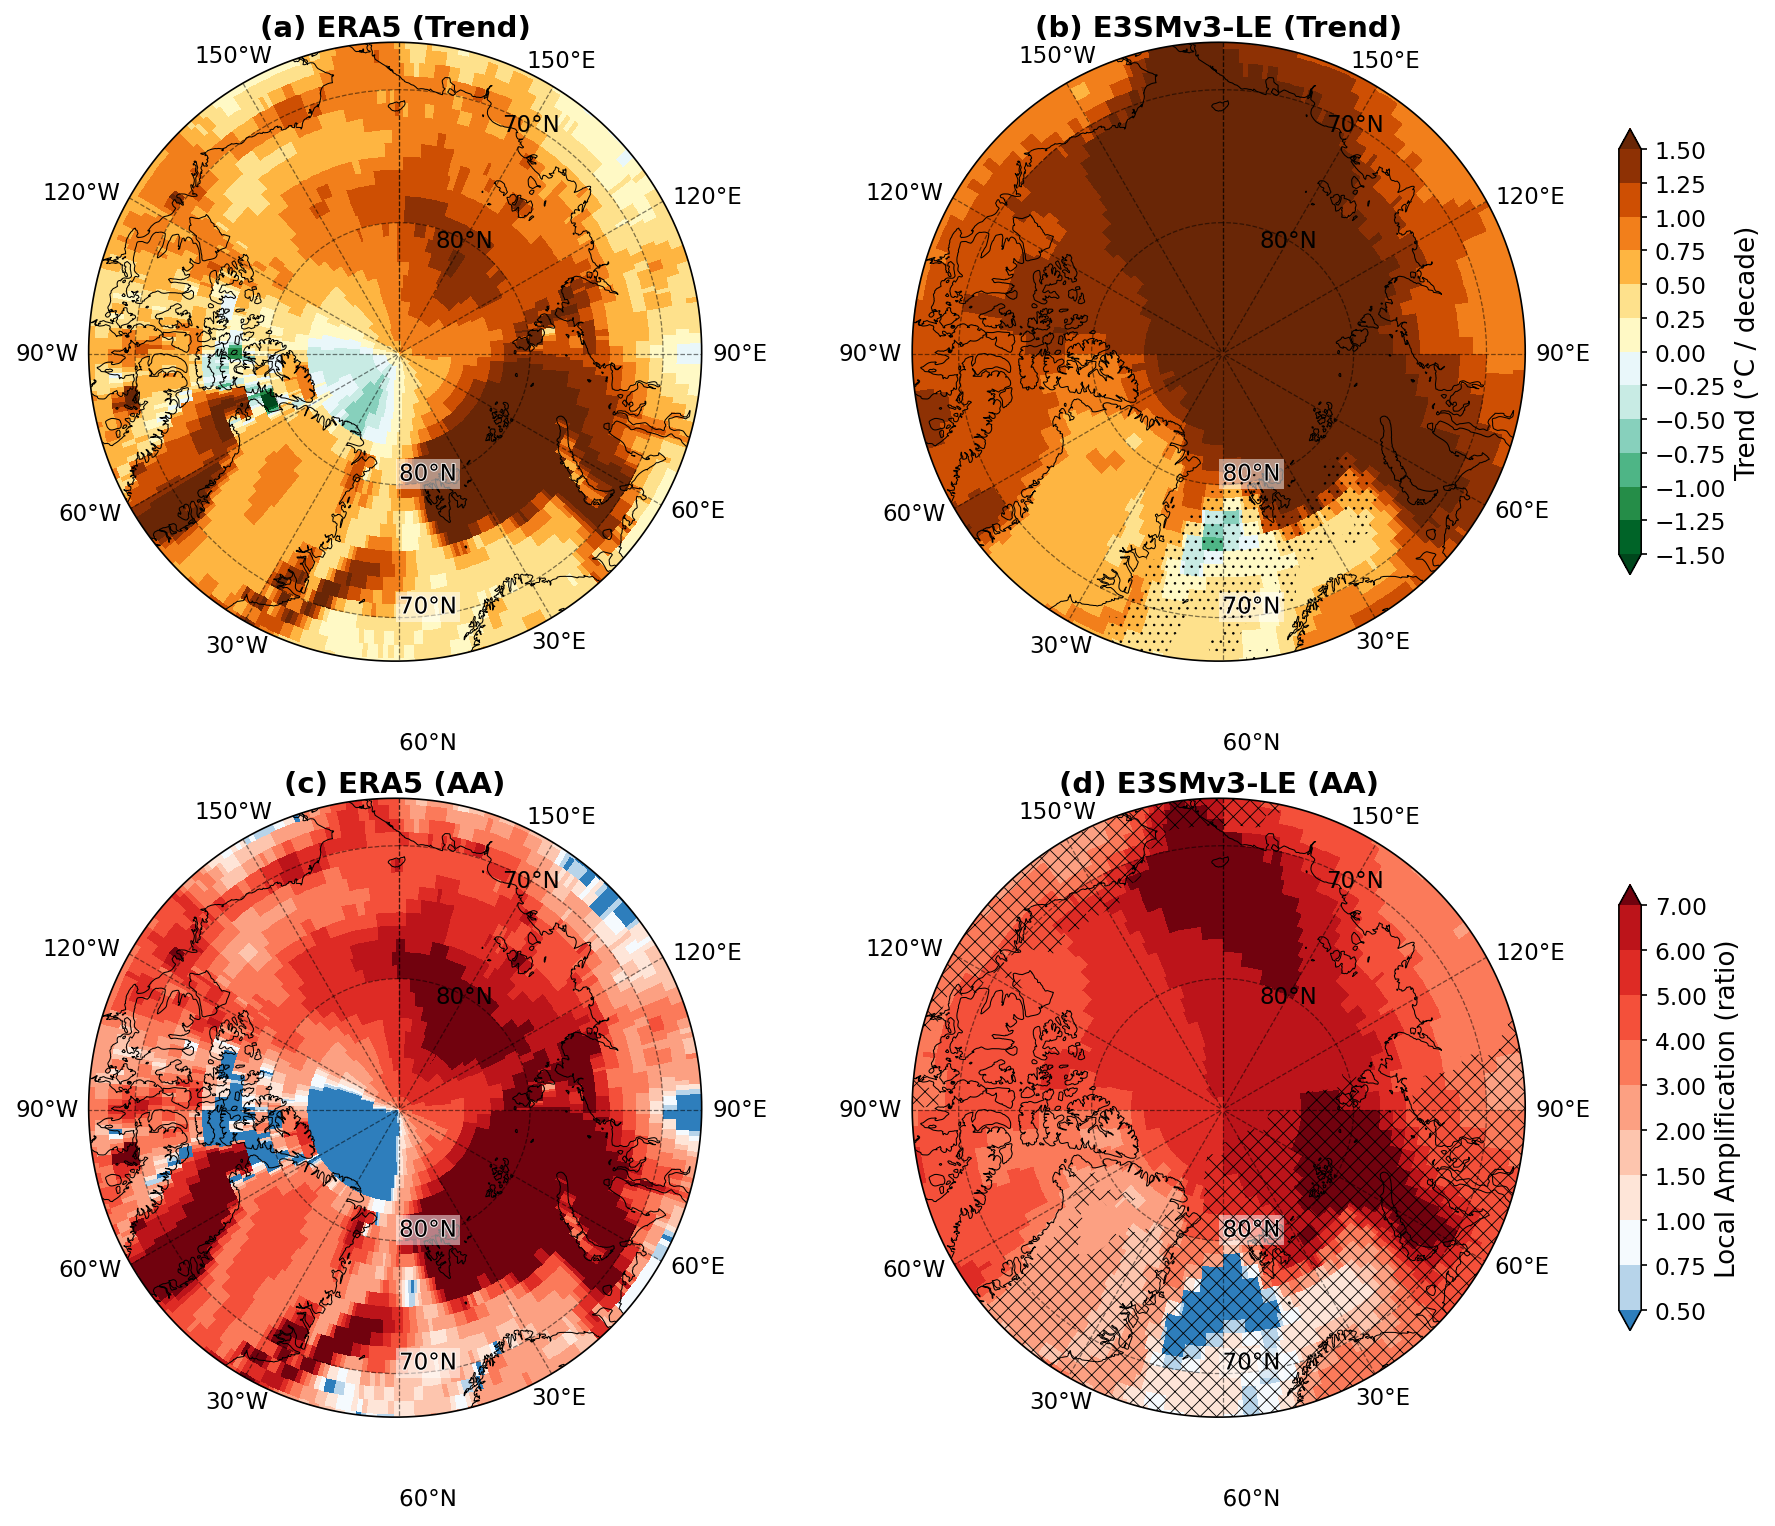

[INFO] Saved: ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_DJF.pdf
[INFO] season MAM: only 1 members — using fallbacks.
[MAM ERA5 trend] kind=low_agreement, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[MAM E3SMv3-LE trend] kind=low_agreement, agree_lo=0.920, agree_hi=1.000, cv_hi=0.367, std_hi=1.324
[MAM ERA5 AA] kind=high_cv, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[MAM E3SMv3-LE AA] kind=high_cv, agree_lo=0.920, agree_hi=1.000, cv_hi=0.367, std_hi=1.324


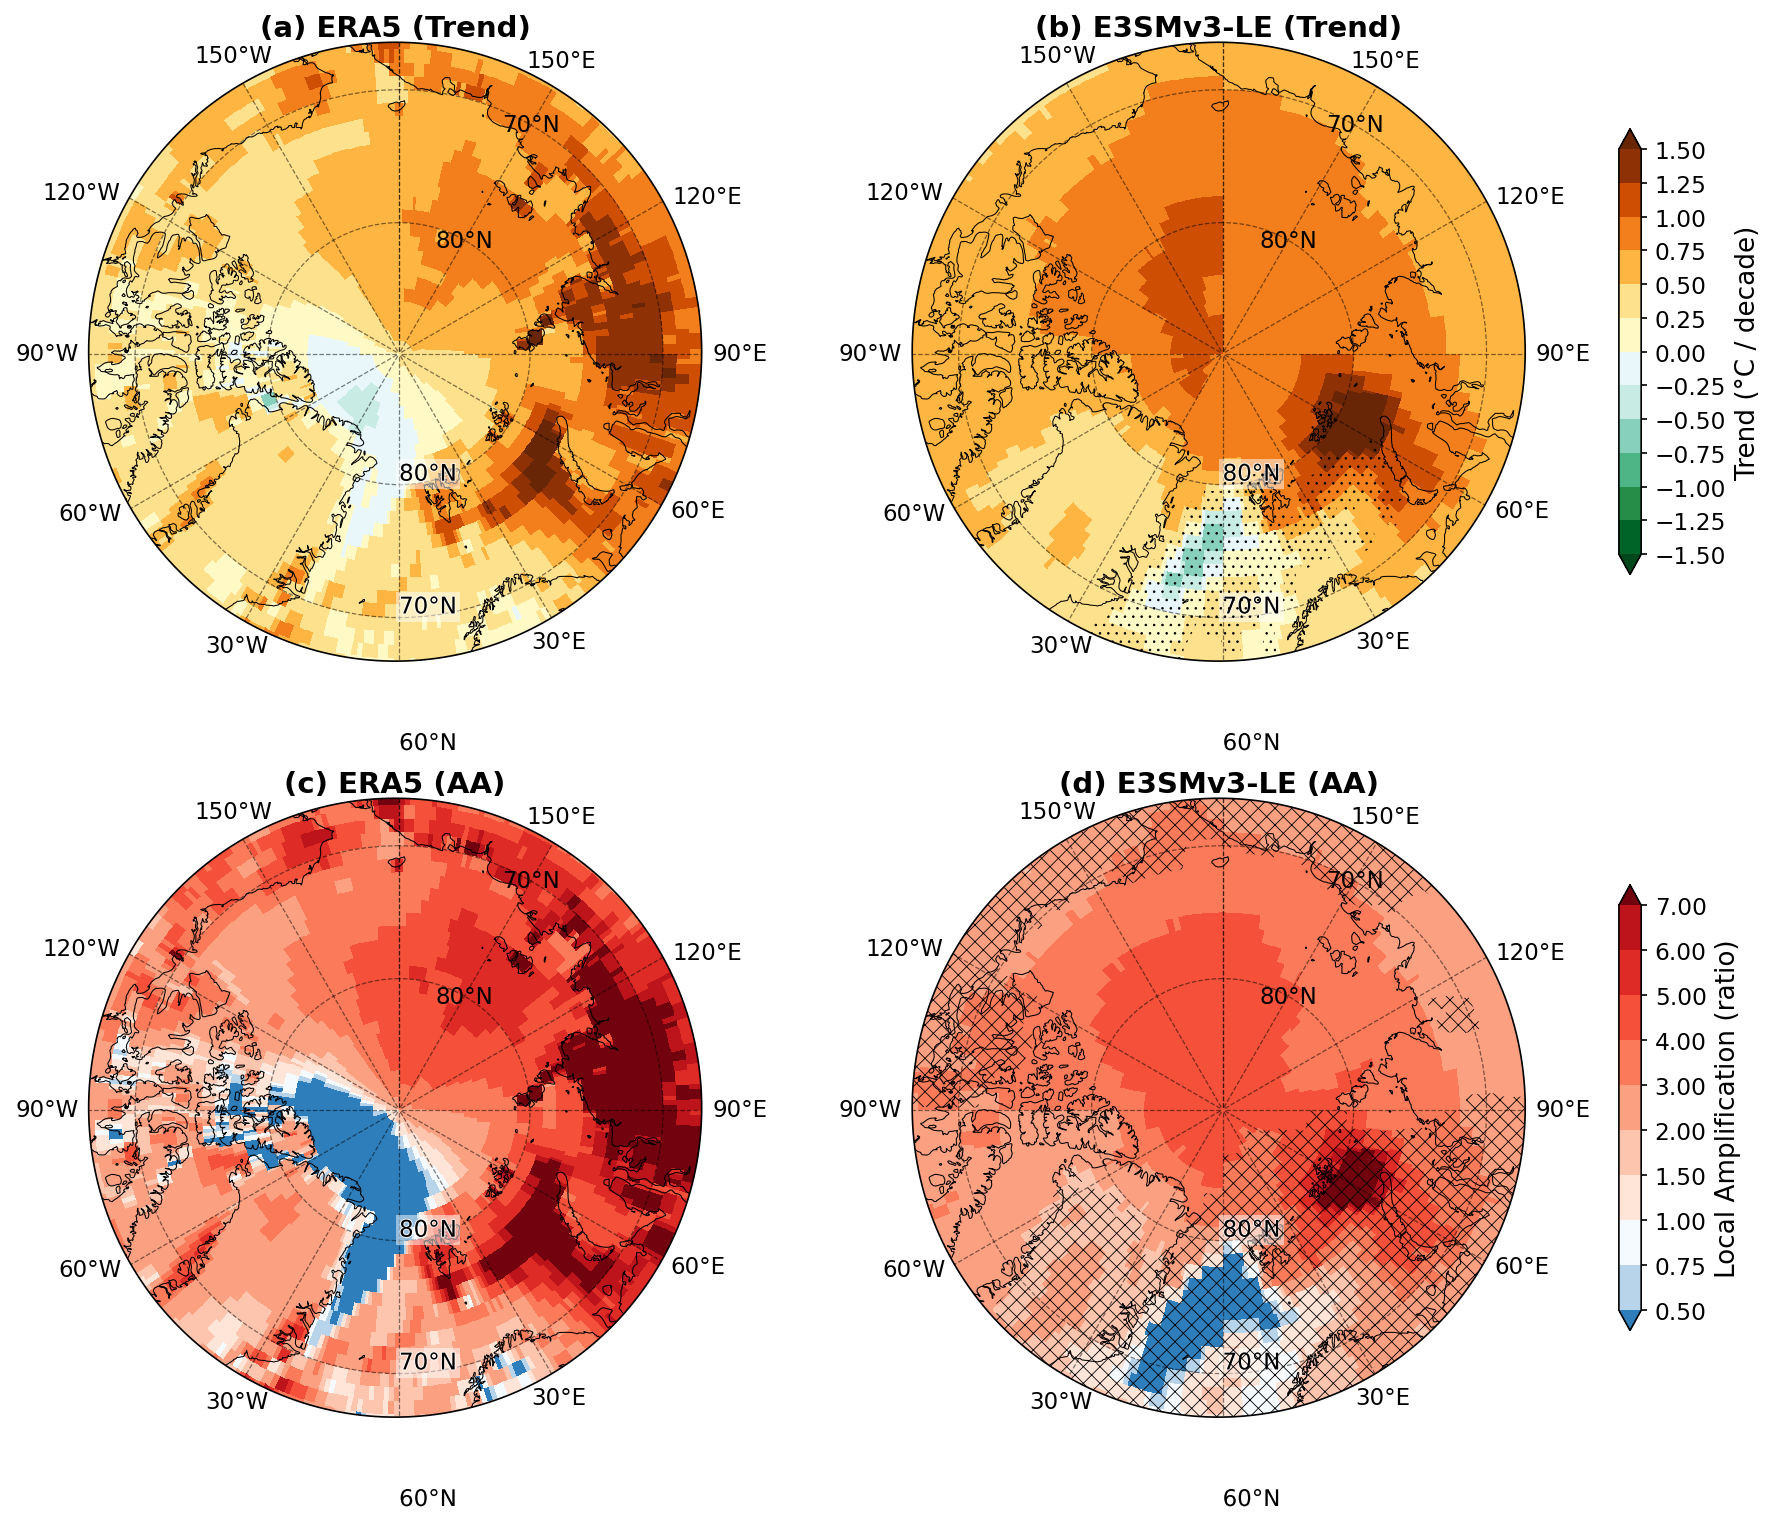

[INFO] Saved: ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_MAM.pdf
[INFO] season JJA: only 1 members — using fallbacks.
[JJA ERA5 trend] kind=low_agreement, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[JJA E3SMv3-LE trend] kind=low_agreement, agree_lo=0.880, agree_hi=1.000, cv_hi=0.478, std_hi=0.660
[JJA ERA5 AA] kind=high_cv, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[JJA E3SMv3-LE AA] kind=high_cv, agree_lo=0.880, agree_hi=1.000, cv_hi=0.478, std_hi=0.660


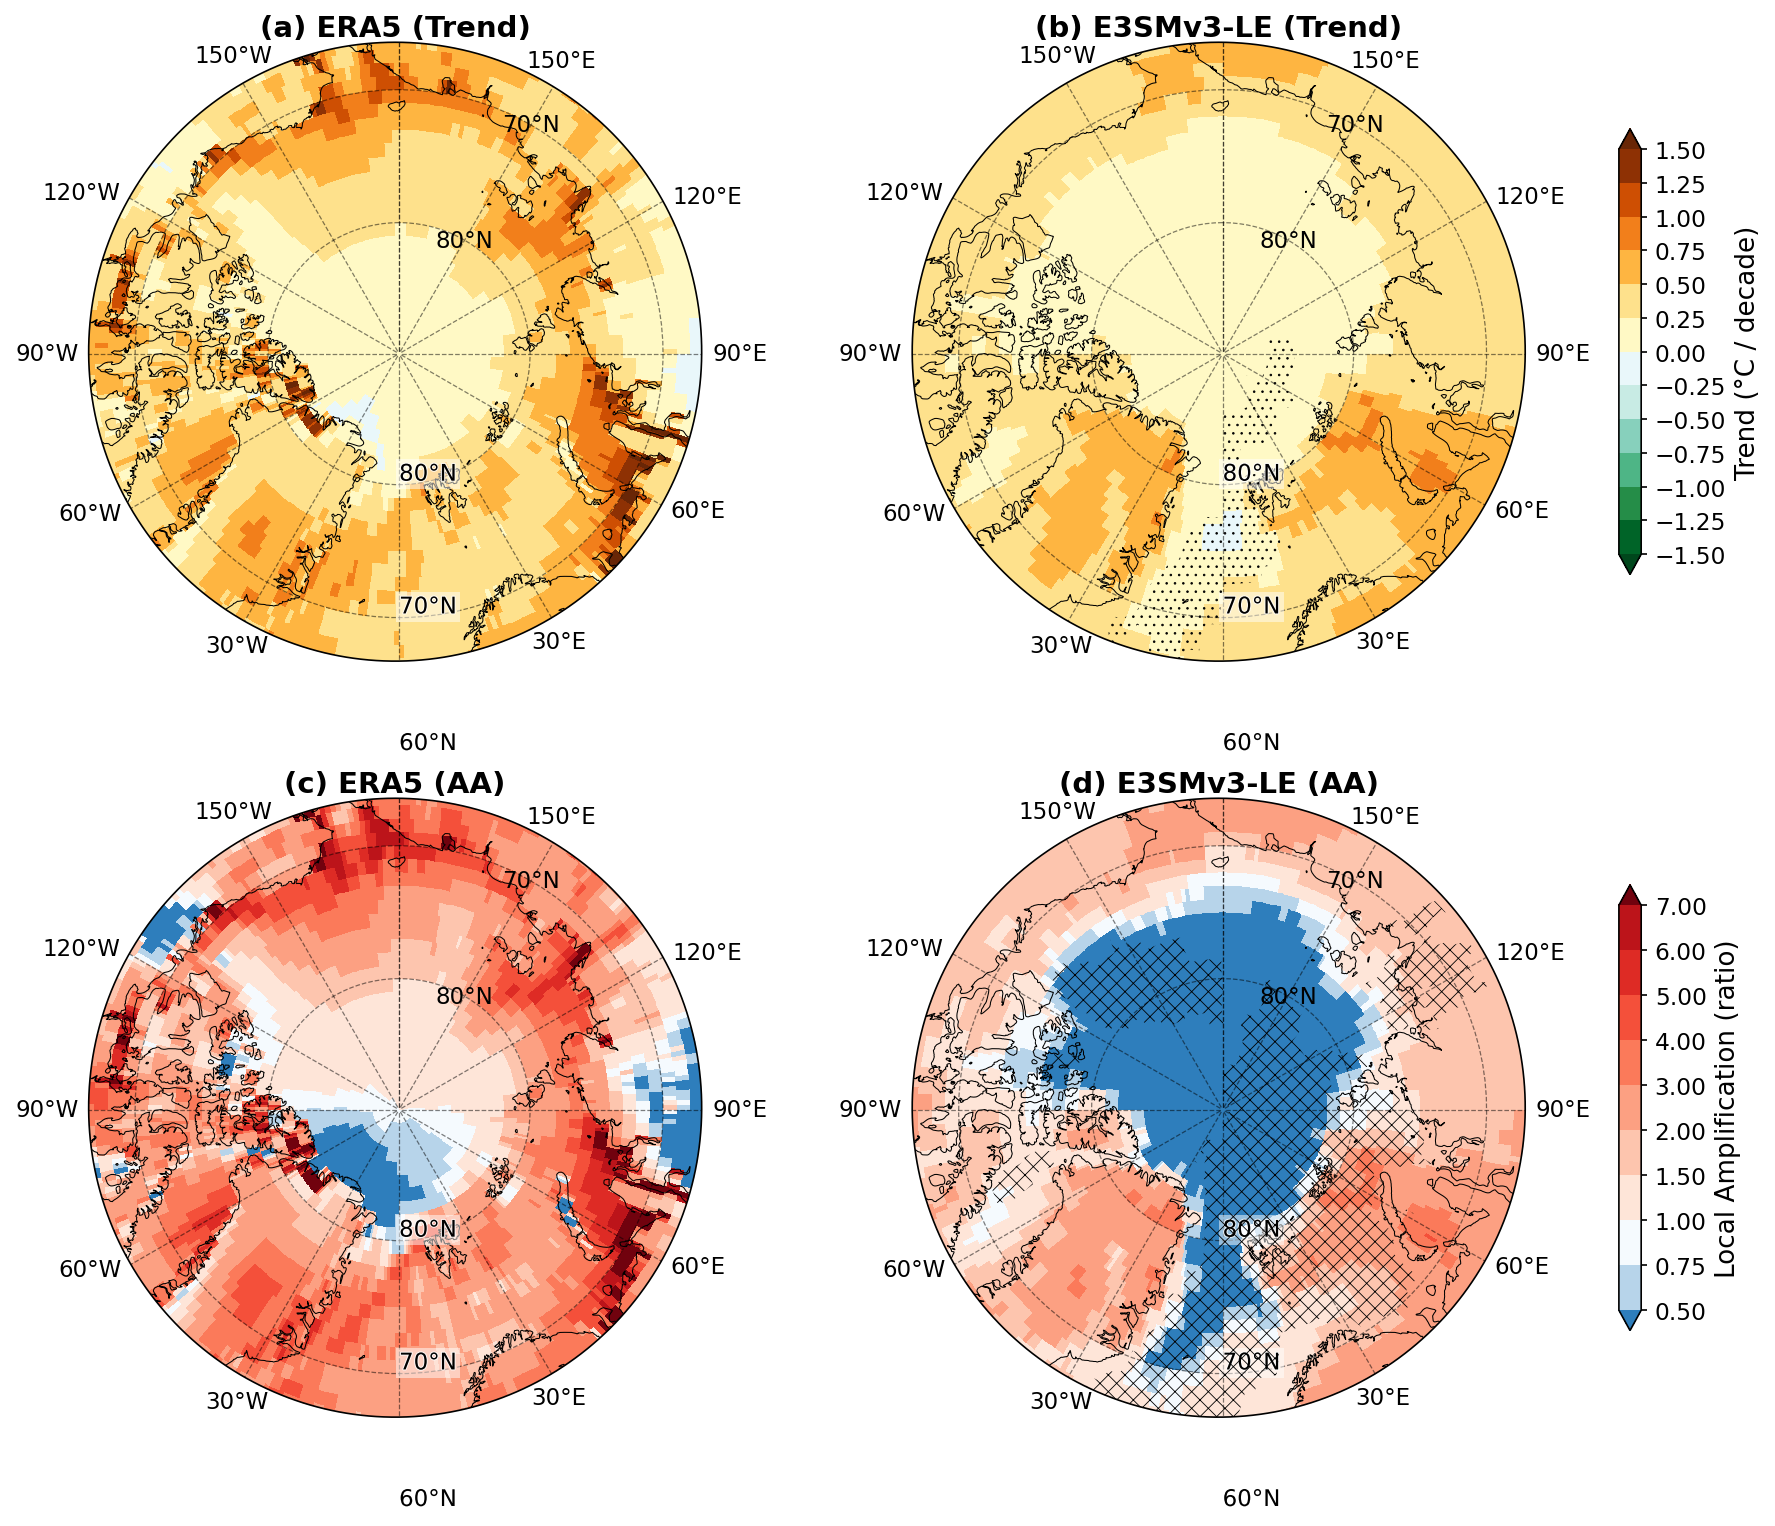

[INFO] Saved: ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_JJA.pdf
[INFO] season SON: only 1 members — using fallbacks.
[SON ERA5 trend] kind=low_agreement, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[SON E3SMv3-LE trend] kind=low_agreement, agree_lo=0.960, agree_hi=1.000, cv_hi=0.265, std_hi=1.306
[SON ERA5 AA] kind=high_cv, agree_lo=0.600, agree_hi=0.800, cv_hi=0.500, std_hi=0.500
[SON E3SMv3-LE AA] kind=high_cv, agree_lo=0.960, agree_hi=1.000, cv_hi=0.265, std_hi=1.306


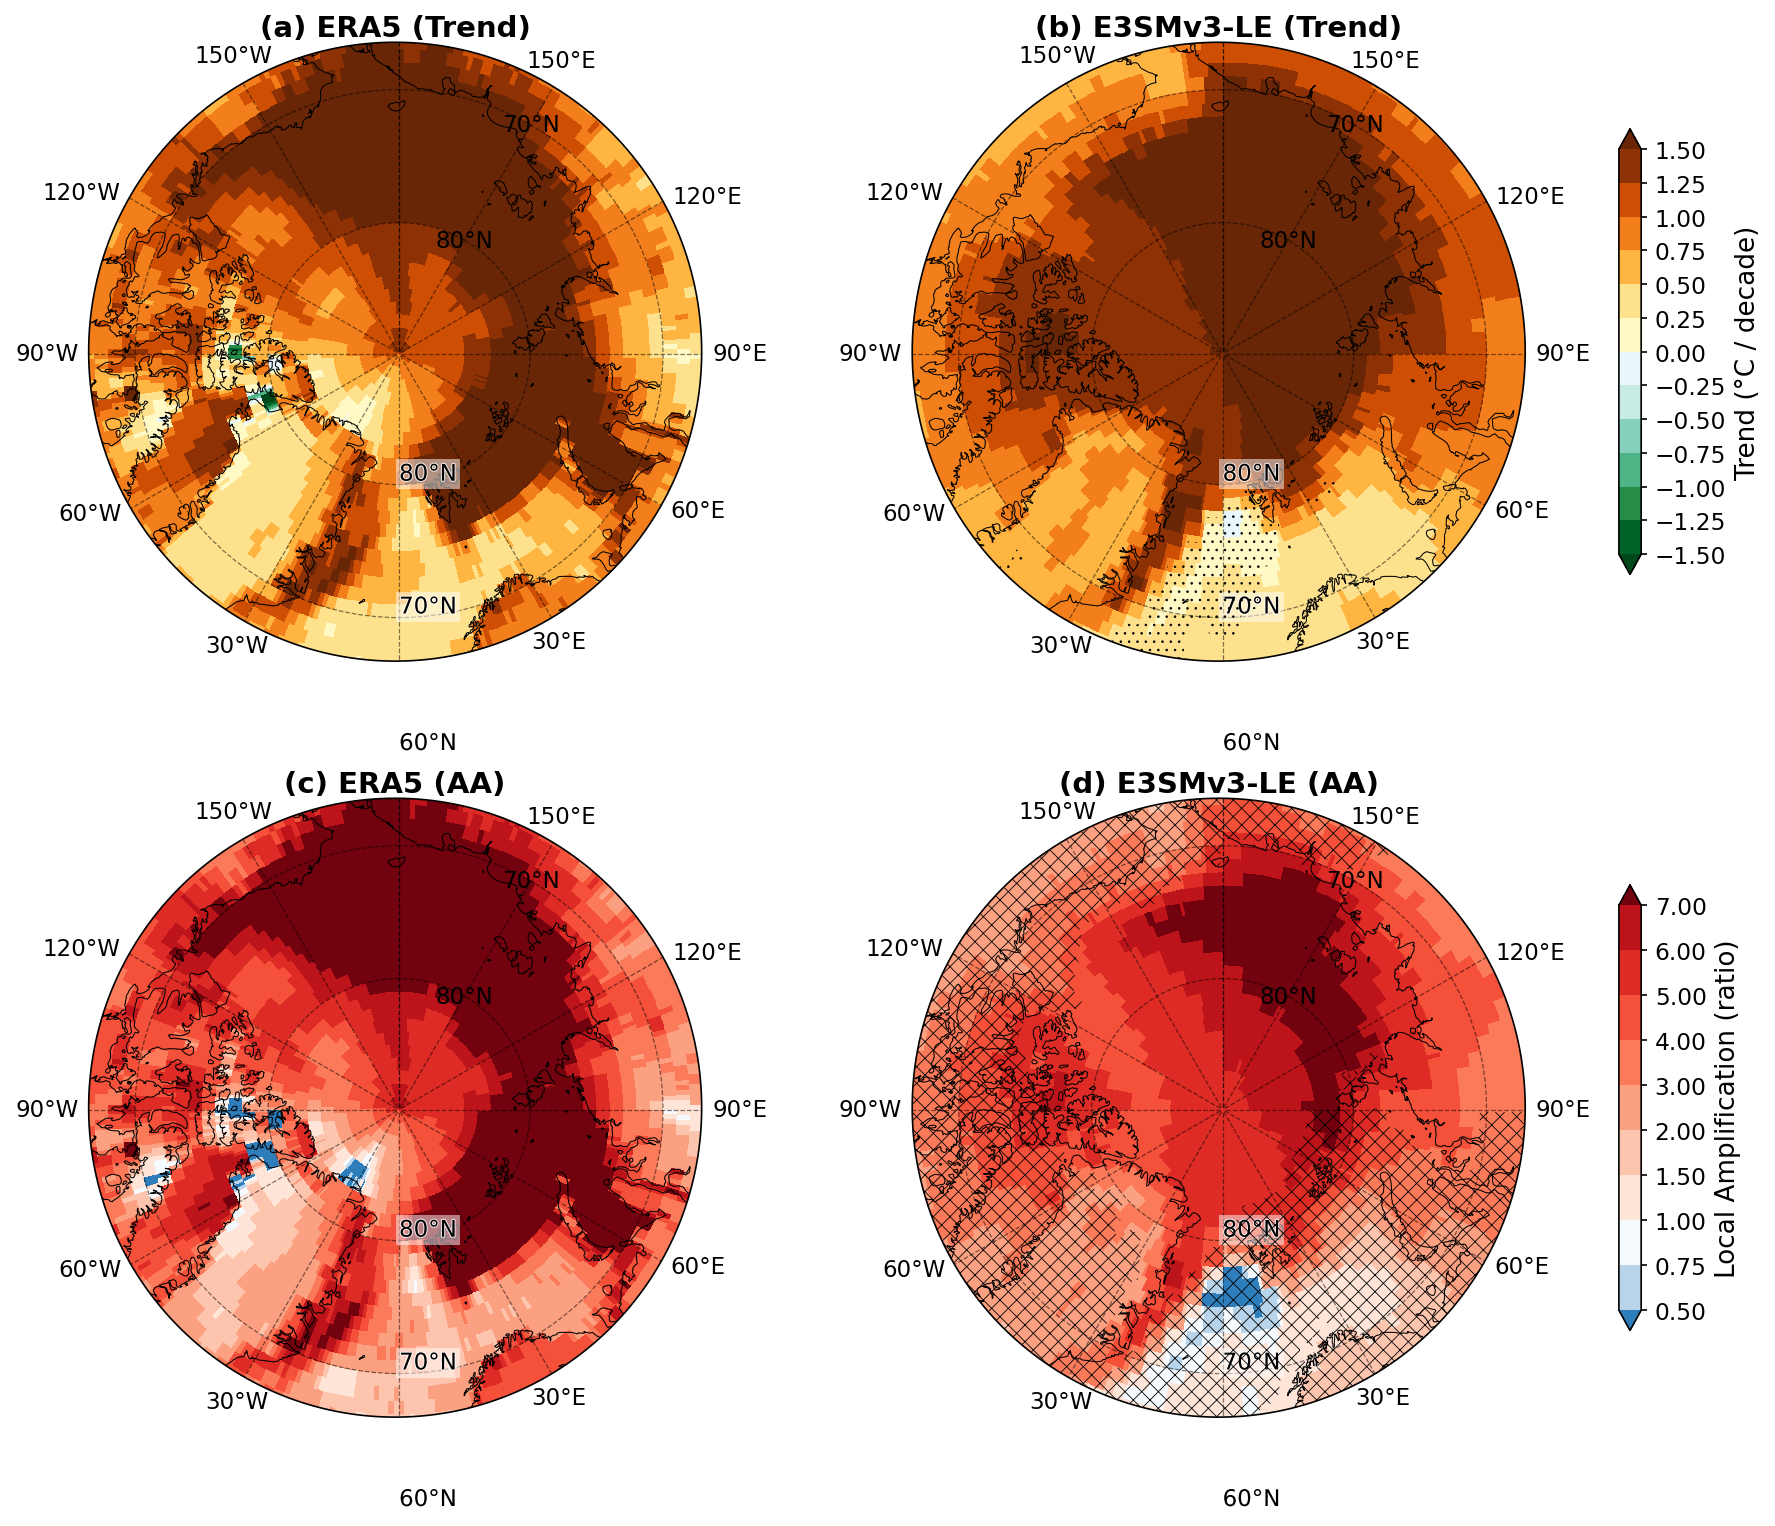

[INFO] Saved: ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_SON.pdf
[OK] ANN: saved to ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_ANN.pdf
[OK] DJF: saved to ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_DJF.pdf
[OK] MAM: saved to ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_MAM.pdf
[OK] JJA: saved to ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_JJA.pdf
[OK] SON: saved to ./figures/Trend_AA_compare_ERA5__vs__E3SMv3-LE_SON.pdf


In [8]:
if __name__ == "__main__":
    TOP_DIR = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    OUT_DIR = str(V3LE_DIAG_DIR)
    FIG_DIR = str(FIG_DIR_ROOT)
    os.makedirs(FIG_DIR, exist_ok=True)
    
    region_dict = {
        "arctic": {"name": "Arctic2", "lat_range": (66.5, 90.0),  "lon_range": (-180, 180)},
        "global": {"name": "global", "lat_range": (-90.0, 90.0), "lon_range": (-180, 180)},
    }
    
    EXPS    = ["ERA5", "E3SMv3-LE"]
    GROUPS  = ["ERA5", "v3.LR.historical"]
    VAR     = "TS"
    PTARGT  = (1979, 2018)
    SEASONS = ["ANN", "DJF", "MAM", "JJA", "SON"]

    PREFIX_A = f"AA2_driftcorr_{EXPS[0]}_{GROUPS[0]}_{VAR}"
    PREFIX_B = f"AA2_driftcorr_{EXPS[1]}_{GROUPS[1]}_{VAR}"
    PATTERN  = "{prefix}_{season}_arctic_{start}-{end}.mean.nc"

    # Discrete bin edges (used for categorical colorbar)
    trend_edges = (-1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5)
    aa_edges    = (0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0)

    # Plot appearance
    use_polar = True
    projection = "north_polar"
    subset_lat = region_dict["arctic"]['lat_range']
    figsize = (12, 10)
    dpi = 150
    trend_cmap = "coolwarm"
    show = True
    fontz = 14
    lat_name, lon_name = "lat", "lon"

    wspace = 0.02
    hspace = 0.02
    constrained = True
    cbar_shrink = 0.72
    cbar_pad = 0.018
    cbar_fraction = 0.045

    # Ensemble member paths (pattern can include {season})
    members_glob_A = f"{OUT_DIR}/{PREFIX_A}_{{season}}_arctic_{PTARGT[0]}-{PTARGT[1]}.members.nc"
    members_glob_B = f"{OUT_DIR}/{PREFIX_B}_{{season}}_arctic_{PTARGT[0]}-{PTARGT[1]}.members.nc"

    # Variability overlays: choose what to visualize
    stippling_for = {"trend": "low_agreement", "aa": "high_cv"}
    stippling_mode = "hatch"   # or "dots"
    stippling_stride = 5
    stippling_size = 4.0
    dots_marker = "."

    # Quantile thresholds → adapt to each season dynamically
    agree_lo_q = 0.10   # or 0.2
    agree_hi_q = 0.90   # lower sign-agreement (5–10%) marks disagreement
    cv_hi_q = 0.60      # top 40% variability for AA
    std_hi_q = 0.75     # optional, only used if stippling_for uses "high_std"

    # Instantiate plotter
    plotter = ArcticDiagnosticsMapPlotter(
        fig_dir=FIG_DIR,
        fontz=fontz,
        lat_name=lat_name,
        lon_name=lon_name,
    )

    # Run per-season comparisons
    outputs = plotter.plot_compare_from_dirs(
        out_dir_A=OUT_DIR,
        out_dir_B=OUT_DIR,
        prefix_A=PREFIX_A,
        prefix_B=PREFIX_B,
        seasons=SEASONS,
        start_end=PTARGT,
        pattern=PATTERN,
        exp_A=EXPS[0],
        exp_B=EXPS[1],
        # Layout and color controls
        figsize=figsize,
        dpi=dpi,
        use_polar=use_polar,
        projection=projection,
        subset_lat=subset_lat,
        dateline_stitch=True,
        rasterize=True,
        constrained=constrained,
        wspace=wspace,
        hspace=hspace,
        cbar_shrink=cbar_shrink,
        cbar_pad=cbar_pad,
        cbar_fraction=cbar_fraction,
        trend_cmap=trend_cmap,
        trend_edges=trend_edges,
        aa_edges=aa_edges,
        show=show,
        # Ensemble overlays
        members_glob_A=members_glob_A,
        members_glob_B=members_glob_B,
        stippling_for=stippling_for,
        stippling_mode=stippling_mode,
        stippling_stride=stippling_stride,
        stippling_size=stippling_size,
        dots_marker=dots_marker,
        agree_lo_q=agree_lo_q,
        agree_hi_q=agree_hi_q,
        cv_hi_q=cv_hi_q,
        std_hi_q=std_hi_q,
    )

    for s, path in outputs.items():
        print(f"[OK] {s}: saved to {path}")
